### Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import sklearn
import keras
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
frSm sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from keras.layers import Input, Dropout, Dense, BatchNormalization
from keras.models import Sequential
from keras import regularizers
from keras.callbacks import EarlyStopping

### Tratamento de Dados Básico

In [2]:
# armazenando o nome das colunas numéricas (listadas na página do UCI) do dataset em um vetor
columns = ['Altitude','Orientação','Inclinação','Distância_Horizontal_Hidrologia','Distância_Vertical_Hidrologia',
    'Distância_Horizontal_Rodovias','Sombreamento_9h','Sombreamento_12h','Sombreamento_15h','Distância_Horizontal_Pontos_Fogo']
# adicionando o nome das colunas categóricas referente ao tipo de área selvagem considerando a estratégia one-hot enconding
columns += [f'Area_Selvagem_{i}' for i in range(4)]
# adicionando o nome das colunas categóricas referente ao tipo de solo considerando a estratégia one-hot enconding
columns += [f'Tipo_Solo_{i}' for i in range(40)]
# adicionando o nome da coluna referente ao rótulo
columns += ['Tipo_Cobertura_Florestal']

Importação do dataset e tratamento dos dados

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz" # buscando o endereço do dataset

data = pd.read_csv(url, header=None, names=columns) # realizando a leitura e nomeando as colunas do dataframe com a lista criada

data = data.dropna().copy() # excluindo qualquer linha que possua valores nulos em alguma das colunas
data['Tipo_Cobertura_Florestal'] = data['Tipo_Cobertura_Florestal'] - 1 # decrementando em 1 a coluna tipo_cobertura_florestal

data

,Altitude,Orientação,Inclinação,Distância_Horizontal_Hidrologia,Distância_Vertical_Hidrologia,Distância_Horizontal_Rodovias,Sombreamento_9h,Sombreamento_12h,Sombreamento_15h,Distância_Horizontal_Pontos_Fogo,...,Tipo_Solo_31,Tipo_Solo_32,Tipo_Solo_33,Tipo_Solo_34,Tipo_Solo_35,Tipo_Solo_36,Tipo_Solo_37,Tipo_Solo_38,Tipo_Solo_39,Tipo_Cobertura_Florestal
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,4
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,4
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,1
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,1
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396,153,20,85,17,108,240,237,118,837,...,0,0,0,0,0,0,0,0,0,2
581008,2391,152,19,67,12,95,240,237,119,845,...,0,0,0,0,0,0,0,0,0,2
581009,2386,159,17,60,7,90,236,241,130,854,...,0,0,0,0,0,0,0,0,0,2
581010,2384,170,15,60,5,90,230,245,143,864,...,0,0,0,0,0,0,0,0,0,2


Identificando o número de amostras (𝑁) e número de parâmetros (𝑝) do conjunto de dados total

In [4]:
# exibindo o número de amostras (N) e o número de parâmetros (p), respectivamente
print(f"Número de amostras: {data.shape[0]}")
print(f"Número de parâmetros (features): {data.shape[1]}")

Número de amostras: 581012
Número de parâmetros (features): 55


Construindo a matriz 𝑋 e o vetor 𝑦 de entrada para o classificador e separando-os entre treinamento (64%), validação (16%) e teste (20%), a divisão é feita com base na heurística utilizada durante as aulas e na maioria das aplicações para garantir que o modelo seja treinado com uma quantidade considerada de dados e que o Eval seja um bom estimador do Eout

In [5]:
X = np.array(data.drop(['Tipo_Cobertura_Florestal'], axis = 1)) # construindo o vetor de elementos X
y = np.array(data['Tipo_Cobertura_Florestal']) # construindo o vetor de rótulos y

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, random_state = 42, test_size = 0.2) # dividindo o conjunto em 80% para treino e 20% para teste
X_treino, X_val, y_treino, y_val = train_test_split(X_treino, y_treino, random_state = 42, test_size = 0.2) # dividino pegando 20% dos 80% e destinando para validação

print(f"Quantidade de amostras para teste: {X_treino.shape[0]}")
print(f"Quantidade de amostras para validação: {X_val.shape[0]}")
print(f"Quantidade de amostras para teste: {X_teste.shape[0]}")

Quantidade de amostras para teste: 371847
Quantidade de amostras para validação: 92962
Quantidade de amostras para teste: 116203


Realizando o teste de Kolmogorov Smirnov para verificar se a feature Orientação segue ou se aproxima de uma distribuição normal/gaussiana, uma vez que temos uma quantidade de amostras maior que 50

In [6]:
from scipy import stats
d_stat, p_value = stats.kstest(data["Orientação"], 'norm', args = (data["Orientação"].mean(), data["Orientação"].std()))

print("Estatística D:", d_stat)
print("p-valor:", p_value)

if p_value > 0.05:
    print("Conclusão: Os dados seguem ou se aproximam de uma distribuição normal")
else:
    print("Conclusão: Os dados não seguem ou não se aproximam de distribuição uma normal")

Estatística D: 0.10910751249262313
p-valor: 0.0
Conclusão: Os dados não seguem ou não se aproximam de distribuição uma normal


Aplicando a normalização MinMax visto que alguma das features não segue uma distribuição normal/gaussiana

In [7]:
scaler = MinMaxScaler()

X_treino = scaler.fit_transform(X_treino)
X_val = scaler.fit_transform(X_val)
X_teste  = scaler.transform(X_teste)

### Construção do modelo de Random Forest

In [ ]:
def ModelagemRC(X_train, y_train, X_test, Modelo):

    Modelo.fit(X_train, y_train)

    return Modelo.predict(X_test)

In [ ]:
modelo = RandomForestClassifier(random_state=42)

random_forest_predict = ModelagemRC(X_treino, y_treino, X_teste, modelo)

print(classification_report(y_teste, random_forest_predict))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95     42557
           1       0.94      0.97      0.95     56500
           2       0.94      0.96      0.95      7121
           3       0.91      0.82      0.86       526
           4       0.94      0.73      0.82      1995
           5       0.93      0.88      0.91      3489
           6       0.96      0.95      0.95      4015

    accuracy                           0.95    116203
   macro avg       0.94      0.89      0.91    116203
weighted avg       0.95      0.95      0.95    116203



### Construção do modelo baseado em Rede Neural

Utilizando a Teoria da Dimensão VC para calcular a quantidade máxima de neurônios por camada escondida utilizando a fórmula n≤⌊|CT|−1010×(d+2)⌋

In [ ]:
exemplos = data.shape[0]
dimensao = data.shape[1]

neuronios = (exemplos - 10) / (10 * (dimensao + 2))
neuronios = int(neuronios)

print(f"Quantidade máxima de neurônios por camada escondida: {neuronios}")

Quantidade máxima de neurônios por camada escondida: 1019


A Dimensão VC de uma Rede Neural é o valor aproximado da quantidade de parâmetros (pesos) que a rede possui, por sua vez, a "Regra de Ouro" diz que, dada a Dimensão VC de um modelo de aprendizagem qualquer, para garantirmos a generalização é necessário que o número de amostras para treino seja >= 10dvc. Portando, como temos 371847 exemplos destinados para treino, precisamos de uma Dimensão VC que, quando multiplicada por 10, se aproxime inferiormente pela quantidade de exemplos existente, garantido a generalização do aprendizado

Por sua vez, o Teorema da Aproximação Universal diz que uma rede neural com uma única camada escondida pode aproximar qualquer função contínua em subconjuntos compactos de ℝc. Portando, considerando o limite máximo de neurônios por camada escondida, a "Regra de Ouro" da Dimensão VC e considerando um problema de Classificação Multiclasse, a arquitetura de rede neural é criada

In [ ]:
model = Sequential()

# entrada
model.add(Input(shape=(54,)))

# camada escondida com 597 neurônios
model.add(Dense(597, kernel_initializer='he_normal', activation='relu'))

# camada de saída com 7 neurônios (um para cada cada classe)
model.add(Dense(7, kernel_initializer='he_normal', activation='softmax')) # função de ativação softmax para classificação multiclasse

# obtém os pesos iniciais da rede
initial_weights = model.get_weights()

# compila o modelo, loss = sparse_categorial_crossentropy pois estamos lidando com classificação multiclasse e o y não está no padrão one-hot enconding
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 597)            │        32,835 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 7)              │         4,186 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,021 (144.61 KB)

 Trainable params: 37,021 (144.61 KB)

 Non-trainable params: 0 (0.00 B)

None


Como podemos observar, a rede neural possui um total de 37.021 parâmetros (dvc = 37.021), o que, segundo a "Regra de Ouro", indica que precisamos de pelo menos 370.210 exemplos de treino para garantir a generalização do aprendizado, o que é satisfeito, visto que possuímos 371.847 dados destinamos para o treinamento

In [ ]:
model.set_weights(initial_weights)
history = model.fit(X_treino, y_treino, epochs=100, batch_size=64, validation_data=(X_val, y_val))

Epoch 1/100
5811/5811 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.7347 - loss: 0.6194 - val_accuracy: 0.7627 - val_loss: 0.5605
Epoch 2/100
5811/5811 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.7671 - loss: 0.5383 - val_accuracy: 0.7734 - val_loss: 0.5265
Epoch 3/100
5811/5811 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.7797 - loss: 0.5055 - val_accuracy: 0.7903 - val_loss: 0.4864
Epoch 4/100
5811/5811 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.7898 - loss: 0.4834 - val_accuracy: 0.7982 - val_loss: 0.4714
Epoch 5/100
5811/5811 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.7987 - loss: 0.4661 - val_accuracy: 0.8019 - val_loss: 0.4551
Epoch 6/100
5811/5811 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8059 - loss: 0.4509 - val_accuracy: 0.8089 - val_loss: 0.4454
Epoch 7/100
5811/5811 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8109 - loss: 0.4385 - val_accuracy: 0.8113 - val_loss: 0.4363
Epoch 8/100
5811/5811 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8163 -

Exibindo a performance do modelo

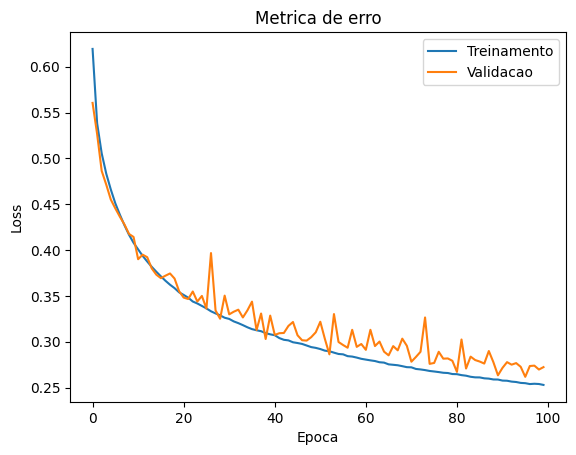


-> Loss_treino = 0.2519
-> Loss_val = 0.2723
-> Loss_val - Loss_treino = 0.0204

-> E_in = 0.1046
-> E_val = 0.1103
-> E_val - E_in = 0.0056

-> Acc_treino: 0.8954
-> Acc_val: 0.8897
-> Acc_treino - Acc_val = 0.0056


In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Loss')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

# obtendo a acurácia no conjunto de treinamento
loss_train, acc_train = model.evaluate(X_treino, y_treino, batch_size=64, verbose=0)

# obtendo a acurácia no conjunto de validação
loss_val, acc_val = model.evaluate(X_val, y_val, batch_size=64, verbose=0)

e_in = 1 - acc_train
e_val = 1 - acc_val

print(f"\n-> Loss_treino = {loss_train:.4f}")
print(f"-> Loss_val = {loss_val:.4f}")
print(f"-> Loss_val - Loss_treino = {loss_val - loss_train:.4f}\n")

print(f"-> E_in = {e_in:.4f}")
print(f"-> E_val = {e_val:.4f}")
print(f"-> E_val - E_in = {e_val - e_in:.4f}\n")

print(f'-> Acc_treino: {acc_train:.4f}')
print(f'-> Acc_val: {acc_val:.4f}')
print(f"-> Acc_treino - Acc_val = {acc_train - acc_val:.4f}")

Computando as métricas de qualidade da melhor rede construída (acurácia, precisão, recall, f1 score)

In [ ]:
y_prob = model.predict(X_teste) # realiza a previsão dos rótulos para o conjunto de teste (retorna um vetor de probabilidades)

y_pred = np.argmax(y_prob, axis=1) # converte as probalidades em classes discretas

print(classification_report(y_teste, y_pred)) # exibe as métricas de qualidade

3632/3632 ━━━━━━━━━━━━━━━━━━━━ 3s 885us/step
              precision    recall  f1-score   support

           0       0.93      0.82      0.87     42557
           1       0.86      0.95      0.91     56500
           2       0.89      0.93      0.91      7121
           3       0.79      0.87      0.82       526
           4       0.86      0.62      0.72      1995
           5       0.88      0.76      0.82      3489
           6       0.93      0.92      0.93      4015

    accuracy                           0.89    116203
   macro avg       0.88      0.84      0.85    116203
weighted avg       0.89      0.89      0.89    116203



### Construção do modelo de Árvore de Decisão


In [10]:
clf = DecisionTreeClassifier(random_state=0)
clf.fit(X_treino, y_treino)

print('Ein: %0.4f' % (1 - accuracy_score(y_treino, clf.predict(X_treino))))
print('Eout: %0.4f' % (1 - accuracy_score(y_teste, clf.predict(X_teste))))
print(classification_report(y_teste, clf.predict(X_teste)))

#Desenho da árvore
plt.figure(figsize=(50,20))
plot_tree(
    clf,
    filled=True, 
    proportion = True,
    fontsize=12, 
    rounded = True)
plt.show()

Ein: 0.0000
Eout: 0.0759
              precision    recall  f1-score   support

           0       0.92      0.93      0.92     42557
           1       0.94      0.93      0.94     56500
           2       0.92      0.92      0.92      7121
           3       0.81      0.83      0.82       526
           4       0.81      0.81      0.81      1995
           5       0.87      0.86      0.86      3489
           6       0.90      0.94      0.92      4015

    accuracy                           0.92    116203
   macro avg       0.88      0.89      0.88    116203
weighted avg       0.92      0.92      0.92    116203



KeyboardInterrupt: 

### Minimal cost complexity

In [ ]:
clf = DecisionTreeClassifier(random_state=0)
path = clf.cost_complexity_pruning_path(X_treino, y_treino)

alphas = np.unique(np.linspace(0, path.ccp_alphas.max(), 50))

param_grid = {'ccp_alpha': alphas}

CV_clf = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, verbose=2, n_jobs=-1)
CV_clf.fit(X_treino, y_treino)

print('Ein: %0.4f' % (1 - accuracy_score(y_treino, CV_clf.predict(X_treino))))
print('Eout: %0.4f' % (1 - accuracy_score(y_teste, CV_clf.predict(X_teste))))
print(classification_report(y_teste, CV_clf.predict(X_teste)))

best_alpha = CV_clf.best_params_['ccp_alpha']
best_tree = CV_clf.best_estimator_
print(f"Melhor ccp_alpha: {best_alpha!r} ({best_alpha:.10e})")

Fitting 5 folds for each of 49 candidates, totalling 245 fits
Ein: 0.3000
Eout: 0.3017
              precision    recall  f1-score   support

           0       0.66      0.74      0.70     42557
           1       0.75      0.74      0.74     56500
           2       0.60      0.88      0.72      7121
           3       0.00      0.00      0.00       526
           4       0.00      0.00      0.00      1995
           5       0.00      0.00      0.00      3489
           6       0.66      0.45      0.53      4015

    accuracy                           0.70    116203
   macro avg       0.38      0.40      0.38    116203
weighted avg       0.67      0.70      0.68    116203

Melhor ccp_alpha: np.float64(0.0017749561379224296) (1.7749561379e-03)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
plt.figure(figsize=(50, 20))
plot_tree(
    best_tree,
    filled=True,
    proportion=True,
    fontsize=12,
    rounded=True
 )
plt.show()

### Implementação de SVM

In [ ]:
rng = np.random.default_rng(42)
n_subset = 50000
idx = rng.choice(X_treino.shape[0], size=min(n_subset, X_treino.shape[0]), replace=False)
X_treino_sub = X_treino[idx]
y_treino_sub = y_treino[idx]

param_grid = {
    'C': [1, 10, 50],
    'gamma': [0.001, 0.01, 0.1],
}
grid = GridSearchCV(estimator=SVC(kernel='rbf'), param_grid=param_grid, cv=3, n_jobs=-1)

%time grid.fit(X_treino_sub, y_treino_sub)
print(grid.best_params_)

clf = grid.best_estimator_

y_pred = clf.predict(X_teste)

print('Ein (subset): %0.4f' % (1 - accuracy_score(y_treino_sub, clf.predict(X_treino_sub))))
print('Eout: %0.4f' % (1 - accuracy_score(y_teste, y_pred)))
print(classification_report(y_teste, y_pred))


In [ ]:
svm_full = SVC(kernel='rbf', C=50, gamma=0.1)

%time svm_full.fit(X_treino, y_treino)

y_pred_full = svm_full.predict(X_teste)

print('Ein (full): %0.4f' % (1 - accuracy_score(y_treino, svm_full.predict(X_treino))))
print('Eout (full): %0.4f' % (1 - accuracy_score(y_teste, y_pred_full)))
print(classification_report(y_teste, y_pred_full))